### LR - Home A

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


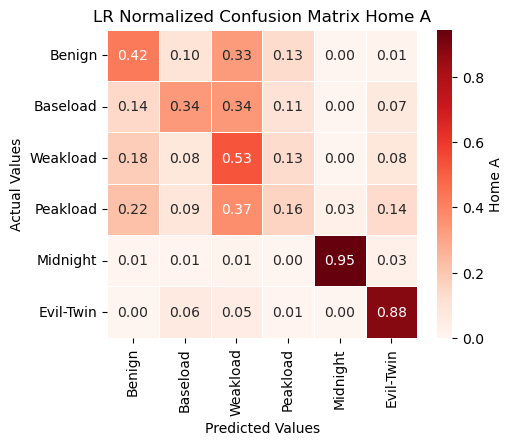

Accuracy Score: 0.28735632183908044
              precision    recall  f1-score   support

           0       0.44      0.42      0.43       146
           1       0.50      0.34      0.40       146
           2       0.33      0.53      0.40       146
           3       0.29      0.16      0.20       140
           4       0.97      0.95      0.96       146
           5       0.73      0.88      0.80       146

    accuracy                           0.55       870
   macro avg       0.54      0.55      0.53       870
weighted avg       0.54      0.55      0.54       870

AUC Score: 0.5719902612146046


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [5]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

## applying standardization - substracting the value from its mean
from sklearn.preprocessing import StandardScaler

# instantiate scaler
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#instantiate the model
lr = LogisticRegression(random_state=42)

# fit our data
lr.fit(X_train_s, y_train)


# Use Model to get prediction
y_predlr2 = lr.predict(X_test_s)
y_predlr2[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predlr2, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('LR Normalized Confusion Matrix Home A')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeA_lr_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predlr2)

# Accuracy score using built in scoring method
accuracy_score = lr.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predlr2))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predlr2_prob = lr.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predlr2_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### LR - Home B

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   526   481   454   450   447   438   449   450   449   441  ...   2066   
1   394   397   273   293   291   275   275   272   274   276  ...   4128   
2   681   445   457   459   459   458   454   401   402   404  ...    905   
3  3256  3378  3494  3339  3380  3435  3333  3383  3329  3455  ...   1202   
4   605   595   600   604   592   594   607   591   588   469  ...    601   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0   2077   2081   2085   2085   2085   2088   2091   2087      4  
1    412    437    435    435    437    437    435    441      3  
2    997    868   2414   2651   2671   2699   2796   2781      1  
3   1225   1205   1149   1187   1156   1142   1154   1292      5  
4    744    737    732    737    730    734    681    652      1  

[5 rows x 1441 columns]
     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   319   352   345   336   352  

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


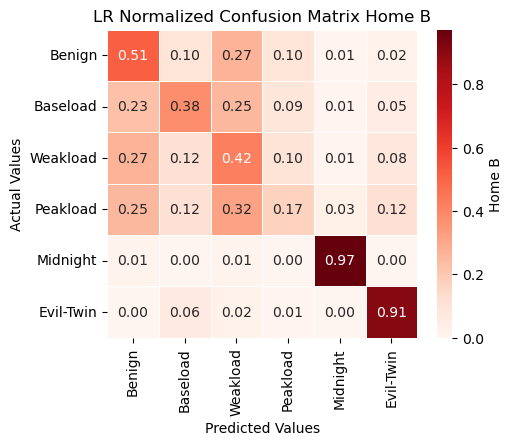

Accuracy Score: 0.313953488372093
              precision    recall  f1-score   support

           0       0.41      0.51      0.46       146
           1       0.50      0.38      0.43       146
           2       0.34      0.42      0.38       146
           3       0.34      0.17      0.23       130
           4       0.95      0.97      0.96       146
           5       0.78      0.91      0.84       146

    accuracy                           0.57       860
   macro avg       0.55      0.56      0.55       860
weighted avg       0.56      0.57      0.55       860

AUC Score: 0.5870978788424396


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [6]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

## applying standardization - substracting the value from its mean
from sklearn.preprocessing import StandardScaler

# instantiate scaler
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#instantiate the model
lr = LogisticRegression(random_state=42)

# fit our data
lr.fit(X_train_s, y_train)


# Use Model to get prediction
y_predlr2 = lr.predict(X_test_s)
y_predlr2[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predlr2, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('LR Normalized Confusion Matrix Home B')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeB_lr_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predlr2)

# Accuracy score using built in scoring method
accuracy_score = lr.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predlr2))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predlr2_prob = lr.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predlr2_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### LR - Home C

    M0   M1   M2   M3   M4   M5   M6   M7   M8    M9  ...  M1431  M1432  \
0  368  366  362  361  360  358  357  238  236   234  ...    231    229   
1  629  553  553  547  554  619  565  561  553   540  ...   1065    742   
2  925  893  880  873  869  850  864  865  862  1008  ...    833    854   
3  302  316  293  327  291  277  275  224  225   223  ...    481    487   
4  519  504  488  488  488  487  486  488  490   489  ...    352    345   

   M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    234    230    228    218    229    229    228      0  
1    757    734    724    731    731    733    630      5  
2    837    840    849    725    735    724    723      5  
3    487    490    214    274    415    457    476      0  
4    341    342    338    340    341    336    335      4  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  461  459  462  465  459  316  326  328  326  328  ...    437    445    455   
1 

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


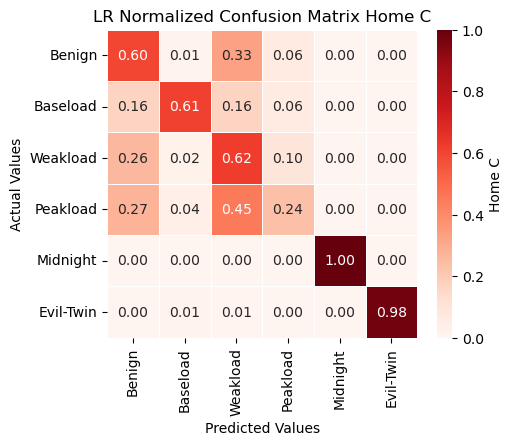

Accuracy Score: 0.20147420147420148
              precision    recall  f1-score   support

           0       0.51      0.60      0.55       146
           1       0.90      0.61      0.73       146
           2       0.45      0.62      0.52       146
           3       0.38      0.24      0.29        84
           4       1.00      1.00      1.00       146
           5       1.00      0.98      0.99       146

    accuracy                           0.71       814
   macro avg       0.71      0.67      0.68       814
weighted avg       0.73      0.71      0.71       814

AUC Score: 0.5149224545039081


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [7]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

## applying standardization - substracting the value from its mean
from sklearn.preprocessing import StandardScaler

# instantiate scaler
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#instantiate the model
lr = LogisticRegression(random_state=42)

# fit our data
lr.fit(X_train_s, y_train)


# Use Model to get prediction
y_predlr2 = lr.predict(X_test_s)
y_predlr2[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_predlr2, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home C'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('LR Normalized Confusion Matrix Home C')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeC_lr_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_predlr2)

# Accuracy score using built in scoring method
accuracy_score = lr.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_predlr2))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_predlr2_prob = lr.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_predlr2_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### RRC - Home A

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   340   341   338   288   289   289   288   292   290   288  ...    805   
1  1353  1380  1388  1276  1258  1253  1245  1248  1269  1261  ...   1310   
2   795   892   831   801   291   342   362   333   343   359  ...    561   
3   435   582   571   559   564   565   567   561   562   570  ...   5733   
4   268   267   266   266   267   268   266   267   267   266  ...   5652   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    842    819    818    782    833    930    818    850      3  
1   1382   1354   1284   1402   1211   1150   1162   1167      5  
2    509    505    528    535    574    384    378    403      0  
3   5130   5114   5148   5158   5180   5259   5196    679      4  
4   5662   5622   5620   5604   5615   5619   5601   5608      0  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  319  304  303  292  302  3

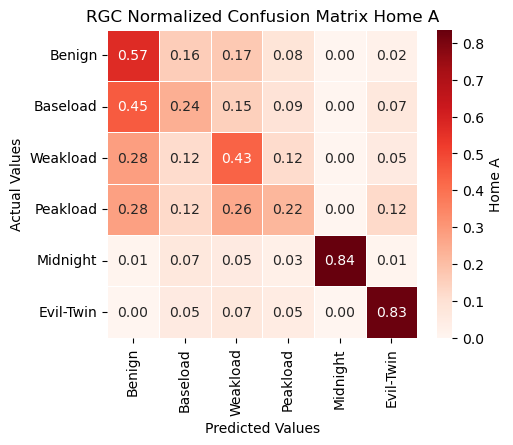

Accuracy Score: 0.27011494252873564
              precision    recall  f1-score   support

           0       0.36      0.57      0.44       146
           1       0.32      0.24      0.27       146
           2       0.38      0.43      0.41       146
           3       0.37      0.22      0.28       140
           4       1.00      0.84      0.91       146
           5       0.76      0.83      0.79       146

    accuracy                           0.52       870
   macro avg       0.53      0.52      0.52       870
weighted avg       0.53      0.52      0.52       870

AUC Score: 0.5114691564584662


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but RidgeClassifier was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [8]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

## applying standardization - substracting the value from its mean

# instantiate scaler
scaler = StandardScaler()


X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#instantiate the model
rgc  = RidgeClassifier(alpha=10, random_state=42)

# fit our data
rgc.fit(X_train_s, y_train)


# Use Model to get prediction
y_pred_rgc = rgc.predict(X_test_s)
y_pred_rgc[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rgc, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('RGC Normalized Confusion Matrix Home A')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeA_rgc_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_pred_rgc)

# Accuracy score using built in scoring method
accuracy_score = rgc.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_rgc))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_rgc_prob = lr.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_rgc_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


### RGC - Home B

     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   526   481   454   450   447   438   449   450   449   441  ...   2066   
1   394   397   273   293   291   275   275   272   274   276  ...   4128   
2   681   445   457   459   459   458   454   401   402   404  ...    905   
3  3256  3378  3494  3339  3380  3435  3333  3383  3329  3455  ...   1202   
4   605   595   600   604   592   594   607   591   588   469  ...    601   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0   2077   2081   2085   2085   2085   2088   2091   2087      4  
1    412    437    435    435    437    437    435    441      3  
2    997    868   2414   2651   2671   2699   2796   2781      1  
3   1225   1205   1149   1187   1156   1142   1154   1292      5  
4    744    737    732    737    730    734    681    652      1  

[5 rows x 1441 columns]
     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   319   352   345   336   352  

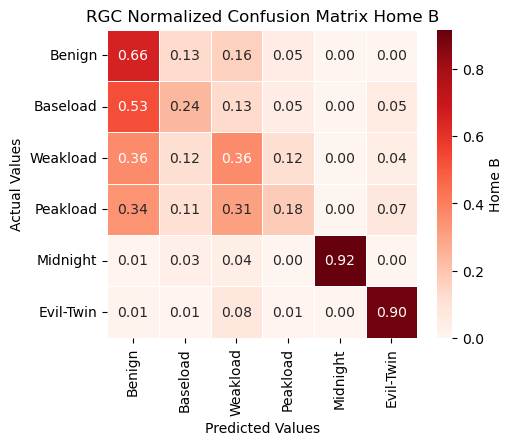

Accuracy Score: 0.3488372093023256
              precision    recall  f1-score   support

           0       0.35      0.66      0.46       146
           1       0.38      0.24      0.30       146
           2       0.35      0.36      0.35       146
           3       0.42      0.18      0.25       130
           4       1.00      0.92      0.96       146
           5       0.85      0.90      0.87       146

    accuracy                           0.55       860
   macro avg       0.56      0.54      0.53       860
weighted avg       0.56      0.55      0.54       860

AUC Score: 0.5076687903823279


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but RidgeClassifier was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [9]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

## applying standardization - substracting the value from its mean

# instantiate scaler
scaler = StandardScaler()


X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#instantiate the model
rgc  = RidgeClassifier(alpha=10, random_state=42)

# fit our data
rgc.fit(X_train_s, y_train)


# Use Model to get prediction
y_pred_rgc = rgc.predict(X_test_s)
y_pred_rgc[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rgc, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('RGC Normalized Confusion Matrix Home B')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeB_rgc_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_pred_rgc)

# Accuracy score using built in scoring method
accuracy_score = rgc.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_rgc))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_rgc_prob = lr.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_rgc_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")

### RGC Home C

    M0   M1   M2   M3   M4   M5   M6   M7   M8    M9  ...  M1431  M1432  \
0  368  366  362  361  360  358  357  238  236   234  ...    231    229   
1  629  553  553  547  554  619  565  561  553   540  ...   1065    742   
2  925  893  880  873  869  850  864  865  862  1008  ...    833    854   
3  302  316  293  327  291  277  275  224  225   223  ...    481    487   
4  519  504  488  488  488  487  486  488  490   489  ...    352    345   

   M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    234    230    228    218    229    229    228      0  
1    757    734    724    731    731    733    630      5  
2    837    840    849    725    735    724    723      5  
3    487    490    214    274    415    457    476      0  
4    341    342    338    340    341    336    335      4  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  461  459  462  465  459  316  326  328  326  328  ...    437    445    455   
1 

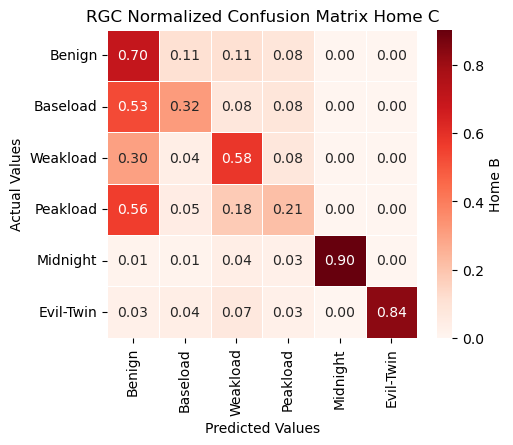

Accuracy Score: 0.27764127764127766
              precision    recall  f1-score   support

           0       0.37      0.70      0.48       146
           1       0.57      0.32      0.41       146
           2       0.59      0.58      0.59       146
           3       0.30      0.21      0.25        84
           4       1.00      0.90      0.95       146
           5       1.00      0.84      0.91       146

    accuracy                           0.62       814
   macro avg       0.64      0.59      0.60       814
weighted avg       0.67      0.62      0.62       814

AUC Score: 0.5149224545039081


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but RidgeClassifier was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

In [10]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

## applying standardization - substracting the value from its mean

# instantiate scaler
scaler = StandardScaler()


X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#instantiate the model
rgc  = RidgeClassifier(alpha=10, random_state=42)

# fit our data
rgc.fit(X_train_s, y_train)


# Use Model to get prediction
y_pred_rgc = rgc.predict(X_test_s)
y_pred_rgc[:5]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rgc, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('RGC Normalized Confusion Matrix Home C')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeC_rgc_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

# accuracy_score(y_test, y_pred_gb)
accuracy_score(y_test, y_pred_rgc)

# Accuracy score using built in scoring method
accuracy_score = rgc.score(X_test, y_test)
# accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_rgc))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_rgc_prob = lr.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_rgc_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")

### Comparison Performance Metric of the Multiclass Classification

In [1]:
import pandas as pd

# Data from the snippet
data = {
    "Models": ["GB", "XGB", "RF", "DTC", "MLP-4", "MLP-3", "LR", "RRC", "SVM"],
    "Accuracy": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
    "Precision": [0.94, 0.94, 0.91, 0.75, 0.70, 0.69, 0.54, 0.53, 0.51],
    "Recall": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
    "F1-score": [0.93, 0.92, 0.87, 0.71, 0.67, 0.66, 0.54, 0.52, 0.51],
    "AUC": [0.99, 0.99, 0.99, 0.82, 0.62, 0.61, 0.57, 0.51, 0.65]
}

# Create DataFrame
df = pd.DataFrame(data)
df


,Models,Accuracy,Precision,Recall,F1-score,AUC
0,GB,0.93,0.94,0.93,0.93,0.99
1,XGB,0.93,0.94,0.93,0.92,0.99
2,RF,0.87,0.91,0.87,0.87,0.99
3,DTC,0.71,0.75,0.71,0.71,0.82
4,MLP-4,0.66,0.70,0.66,0.67,0.62
5,MLP-3,0.66,0.69,0.66,0.66,0.61
6,LR,0.55,0.54,0.55,0.54,0.57
7,RRC,0.52,0.53,0.52,0.52,0.51
8,SVM,0.52,0.51,0.52,0.51,0.65


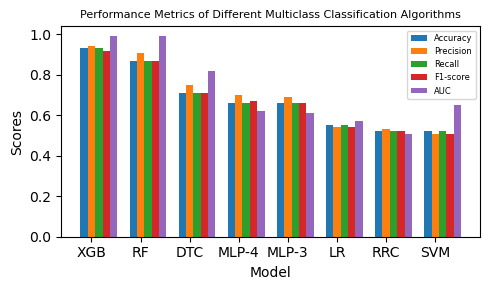

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data based on your table
# Data from the table
data = {
    "Models": ["XGB", "RF", "DTC", "MLP-4", "MLP-3", "LR", "RRC", "SVM"],
    "Accuracy": [0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
   "Precision": [0.94, 0.91, 0.75, 0.70, 0.69, 0.54, 0.53, 0.51],
   "Recall": [0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
    "F1-score": [0.92, 0.87, 0.71, 0.67, 0.66, 0.54, 0.52, 0.51],
     "AUC": [0.99, 0.99, 0.82, 0.62, 0.61, 0.57, 0.51, 0.65]
}

df = pd.DataFrame(data)
n_models = len(df)
bar_width = 0.15  # Width of the bars
index = np.arange(n_models)  # Index for models

# Plotting
plt.figure(figsize=(5, 3))

# Plot each metric
for i, column in enumerate(df.columns[1:]):
    plt.bar(index + i*bar_width, df[column], bar_width, label=column)

plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Performance Metrics of Different Multiclass Classification Algorithms', fontsize=8)
plt.xticks(index + bar_width, df['Models'])
plt.legend(fontsize=6)

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\All_Perf_metric_1.png', bbox_inches='tight')
plt.show()


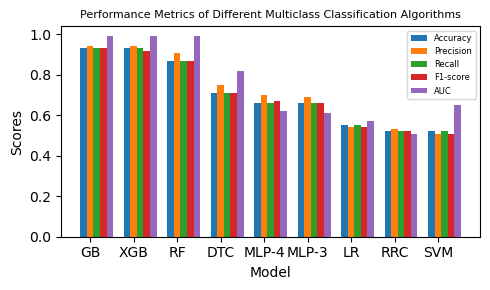

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data based on your table
# Data from the table
data = {
    "Models": ["GB", "XGB", "RF", "DTC", "MLP-4", "MLP-3", "LR", "RRC", "SVM"],
    "Accuracy": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
   "Precision": [0.94, 0.94, 0.91, 0.75, 0.70, 0.69, 0.54, 0.53, 0.51],
   "Recall": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
    "F1-score": [0.93, 0.92, 0.87, 0.71, 0.67, 0.66, 0.54, 0.52, 0.51],
     "AUC": [0.99, 0.99, 0.99, 0.82, 0.62, 0.61, 0.57, 0.51, 0.65]
}

df = pd.DataFrame(data)
n_models = len(df)
bar_width = 0.15  # Width of the bars
index = np.arange(n_models)  # Index for models

# Plotting
plt.figure(figsize=(5, 3))

# Plot each metric
for i, column in enumerate(df.columns[1:]):
    plt.bar(index + i*bar_width, df[column], bar_width, label=column)

plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Performance Metrics of Different Multiclass Classification Algorithms', fontsize=8)
plt.xticks(index + bar_width, df['Models'])
plt.legend(fontsize=6)

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\All_Perf_metric.png', bbox_inches='tight')
plt.show()


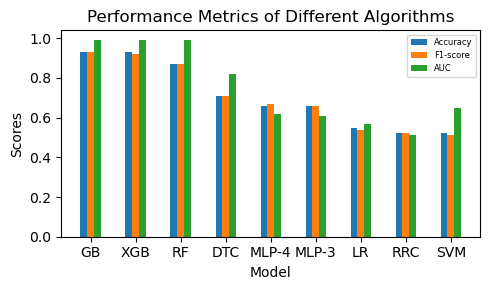

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data based on your table
# Data from the table
data = {
    "Models": ["GB", "XGB", "RF", "DTC", "MLP-4", "MLP-3", "LR", "RRC", "SVM"],
    "Accuracy": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
#    "Precision": [0.94, 0.94, 0.91, 0.75, 0.70, 0.69, 0.54, 0.53, 0.51],
#    "Recall": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
    "F1-score": [0.93, 0.92, 0.87, 0.71, 0.67, 0.66, 0.54, 0.52, 0.51],
     "AUC": [0.99, 0.99, 0.99, 0.82, 0.62, 0.61, 0.57, 0.51, 0.65]
}

df = pd.DataFrame(data)
n_models = len(df)
bar_width = 0.15  # Width of the bars
index = np.arange(n_models)  # Index for models

# Plotting
plt.figure(figsize=(5, 3))

# Plot each metric
for i, column in enumerate(df.columns[1:]):
    plt.bar(index + i*bar_width, df[column], bar_width, label=column)

plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Performance Metrics of Different Algorithms')
plt.xticks(index + bar_width, df['Models'])
plt.legend(fontsize=6)

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Perf_metric_auc.png', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data based on your table
# Data from the table
data = {
    "Models": ["GB", "XGB", "RF", "DTC", "MLP-4", "MLP-3", "LR", "RRC", "SVM"],
    "Accuracy": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
#    "Precision": [0.94, 0.94, 0.91, 0.75, 0.70, 0.69, 0.54, 0.53, 0.51],
#    "Recall": [0.93, 0.93, 0.87, 0.71, 0.66, 0.66, 0.55, 0.52, 0.52],
    "F1-score": [0.93, 0.92, 0.87, 0.71, 0.67, 0.66, 0.54, 0.52, 0.51],
     "AUC": [0.99, 0.99, 0.99, 0.82, 0.62, 0.61, 0.57, 0.51, 0.65]
}

df = pd.DataFrame(data)
n_models = len(df)
bar_width = 0.15  # Width of the bars
index = np.arange(n_models)  # Index for models

# Plotting
plt.figure(figsize=(5, 3))

# Plot each metric
for i, column in enumerate(df.columns[1:]):
    plt.bar(index + i*bar_width, df[column], bar_width, label=column)

plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Performance Metrics of Different Algorithms')
plt.xticks(index + bar_width, df['Models'])
plt.legend(fontsize=6)

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Perf_metric_auc.png', bbox_inches='tight')
plt.show()

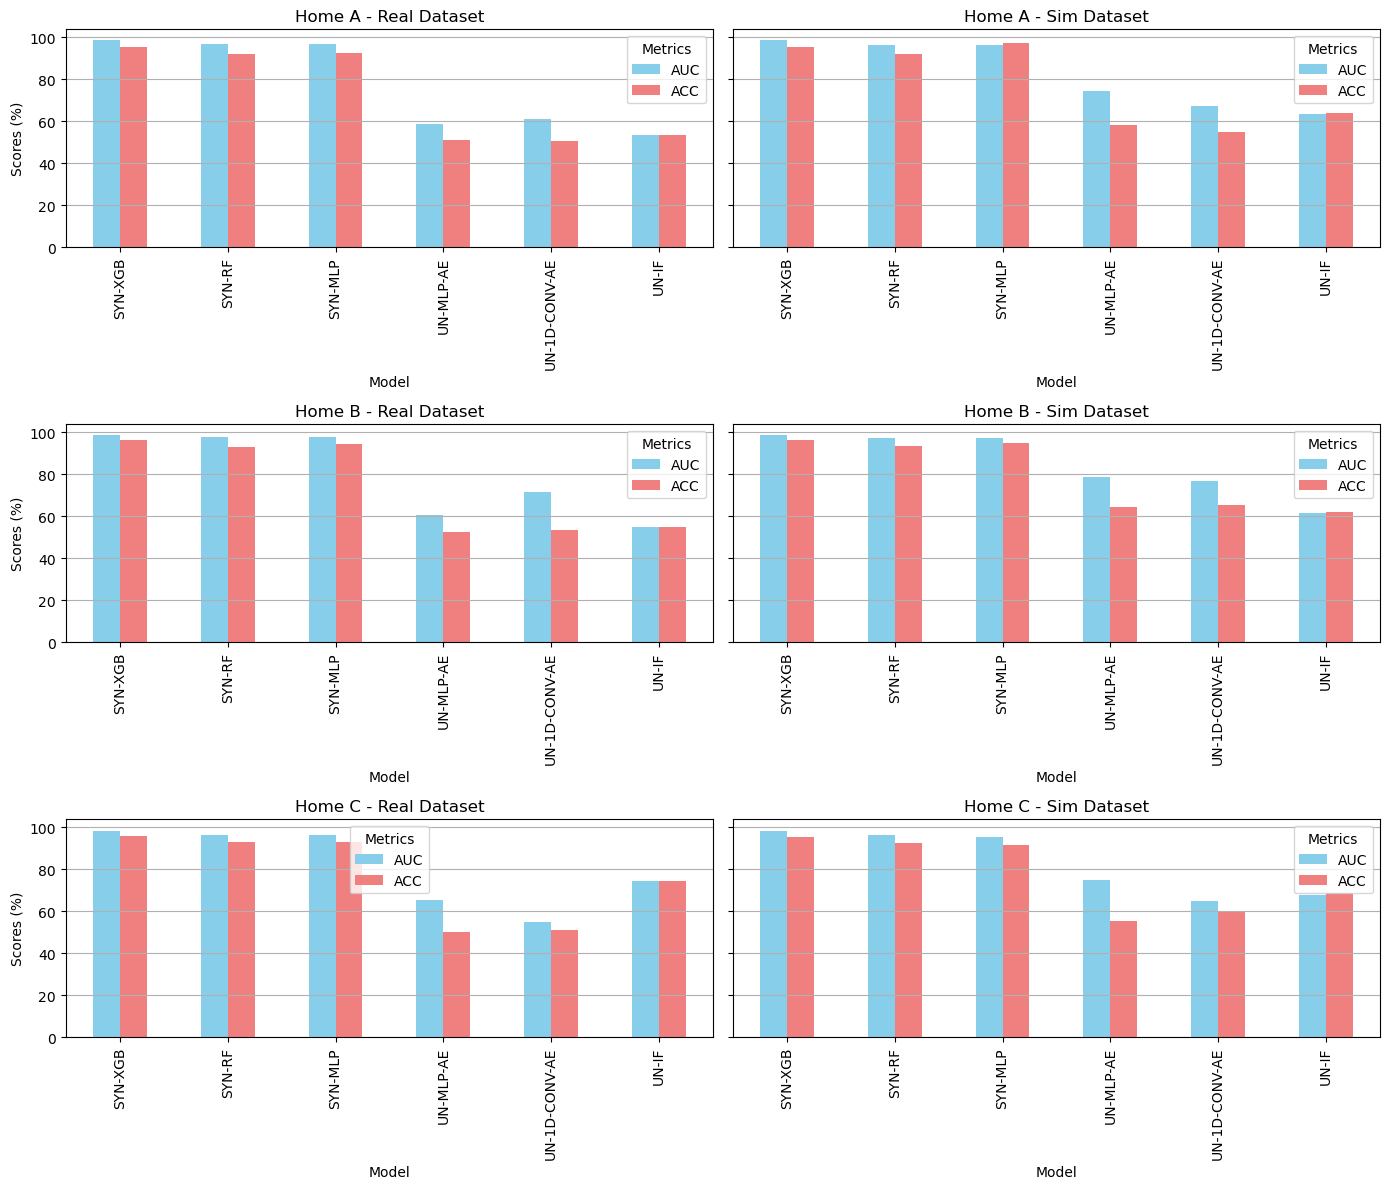

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating a DataFrame from the provided table data
data = {
    "Home": ["A"]*12 + ["B"]*12 + ["C"]*12,
    "DataSet": ["Sim"]*6 + ["Real"]*6 + ["Sim"]*6 + ["Real"]*6 + ["Sim"]*6 + ["Real"]*6,
    "Model": ["SYN-XGB", "SYN-RF", "SYN-MLP", "UN-MLP-AE", "UN-1D-CONV-AE", "UN-IF"] * 6,
    "AUC": [98.76, 96.47, 96.56, 74.61, 67.31, 63.55, 98.91, 97.02, 96.68, 58.96, 61.12, 53.66,
            98.78, 97.56, 97.24, 78.90, 77.04, 61.64, 98.78, 97.64, 97.95, 60.61, 71.77, 55.01,
            98.53, 96.25, 95.37, 75.04, 64.95, 67.66, 98.53, 96.54, 96.49, 65.64, 54.95, 74.35],
    "ACC": [95.21, 91.97, 97.33, 58.28, 54.83, 63.79, 95.55, 92.23, 92.43, 51.26, 50.51, 53.66,
            96.15, 93.59, 95.14, 64.58, 65.63, 62.15, 96.24, 93.27, 94.41, 52.58, 53.58, 55.01,
            95.26, 92.69, 91.68, 55.20, 60.22, 68.82, 95.70, 92.91, 92.93, 50.26, 51.10, 74.35]
}

df = pd.DataFrame(data)

# Plotting AUC and ACC for each model in each dataset
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for i, (home, group_df) in enumerate(df.groupby("Home")):
    for j, (dataset, dataset_df) in enumerate(group_df.groupby("DataSet")):
        ax = axes[i * 2 + j]
        dataset_df.plot(x='Model', y=['AUC', 'ACC'], kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
        ax.set_title(f'Home {home} - {dataset} Dataset')
        ax.set_xlabel('Model')
        ax.set_ylabel('Scores (%)')
        ax.grid(axis='y')
        ax.legend(title="Metrics")

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Perf_metric_ETD.png', bbox_inches='tight')
plt.show()


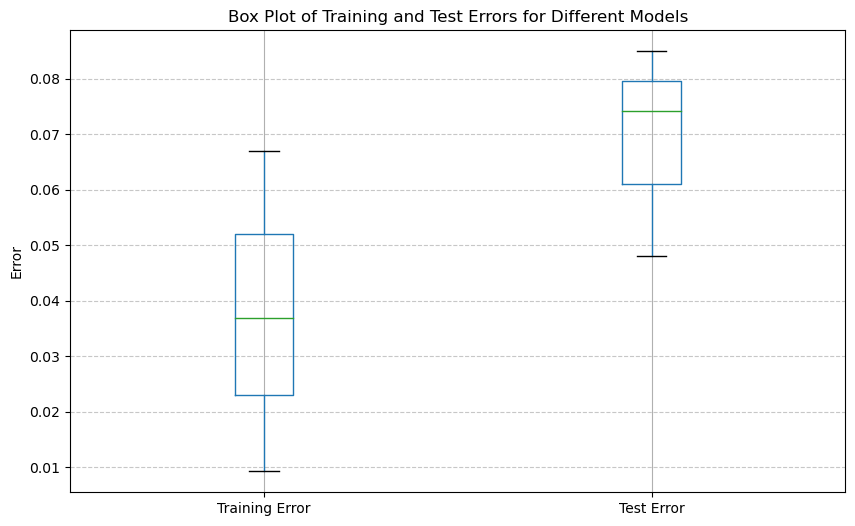

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating a DataFrame from the provided data
data = {
    "Model": ["XGBoost", "Random Forest", "MLP"],
    "Training Error": [0.036915, 0.066976, 0.009276],
    "Test Error": [0.047991, 0.074202, 0.084942]
}

df = pd.DataFrame(data)
# Creating a DataFrame for the box plot
error_types = ['Training Error', 'Test Error']
error_data = pd.DataFrame({etype: df[etype] for etype in error_types})

# Plotting the data as a box plot
plt.figure(figsize=(10, 6))
error_data.boxplot(column=error_types)
plt.title('Box Plot of Training and Test Errors for Different Models')
plt.ylabel('Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


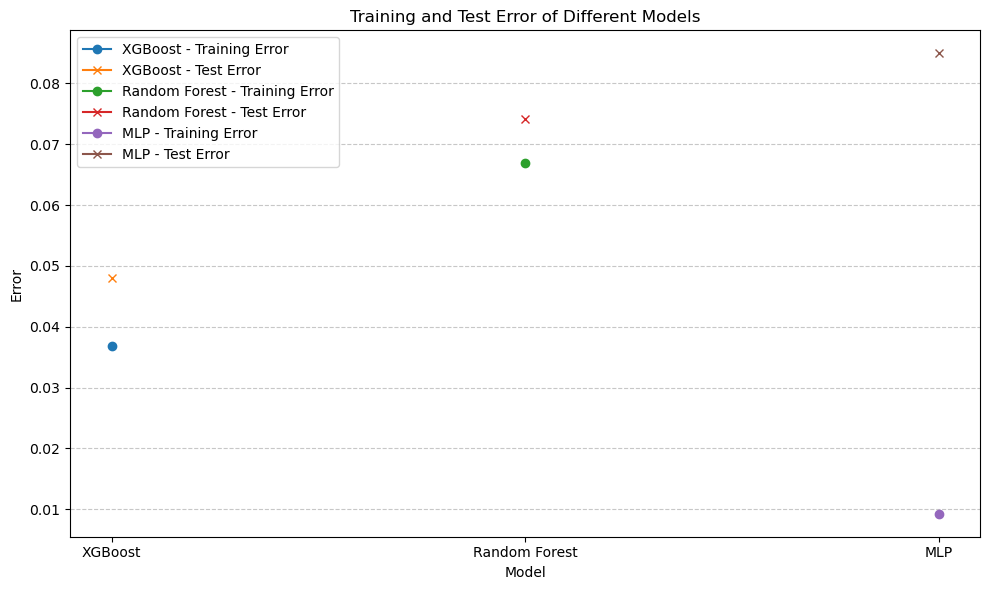

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating a DataFrame from the provided data
data = {
    "Model": ["XGBoost", "Random Forest", "MLP"],
    "Training Error": [0.036915, 0.066976, 0.009276],
    "Test Error": [0.047991, 0.074202, 0.084942]
}

df = pd.DataFrame(data)
# Plotting the data as a line chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting training and test errors for each model
for model in df["Model"]:
    model_data = df[df["Model"] == model]
    ax.plot(model_data["Model"], model_data["Training Error"], marker='o', label=f'{model} - Training Error')
    ax.plot(model_data["Model"], model_data["Test Error"], marker='x', label=f'{model} - Test Error')

plt.title('Training and Test Error of Different Models')
plt.xlabel('Model')
plt.ylabel('Error')
plt.xticks(df["Model"], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()


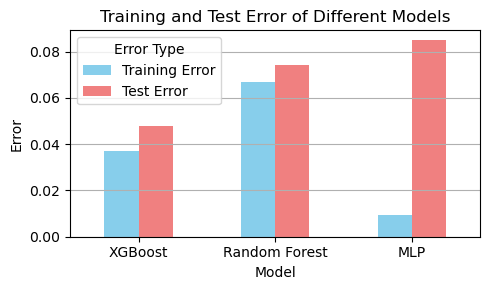

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating a DataFrame from the provided data
data = {
    "Model": ["XGBoost", "Random Forest", "MLP"],
    "Training Error": [0.036915, 0.066976, 0.009276],
    "Test Error": [0.047991, 0.074202, 0.084942]
}

df = pd.DataFrame(data)

# Plotting the data
fig, ax = plt.subplots(figsize=(5, 3))
df.plot(x='Model', y=['Training Error', 'Test Error'], kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
plt.title('Training and Test Error of Different Models')
plt.xlabel('Model')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title="Error Type")
plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Train_&_Test_error.png', bbox_inches='tight')
plt.show()


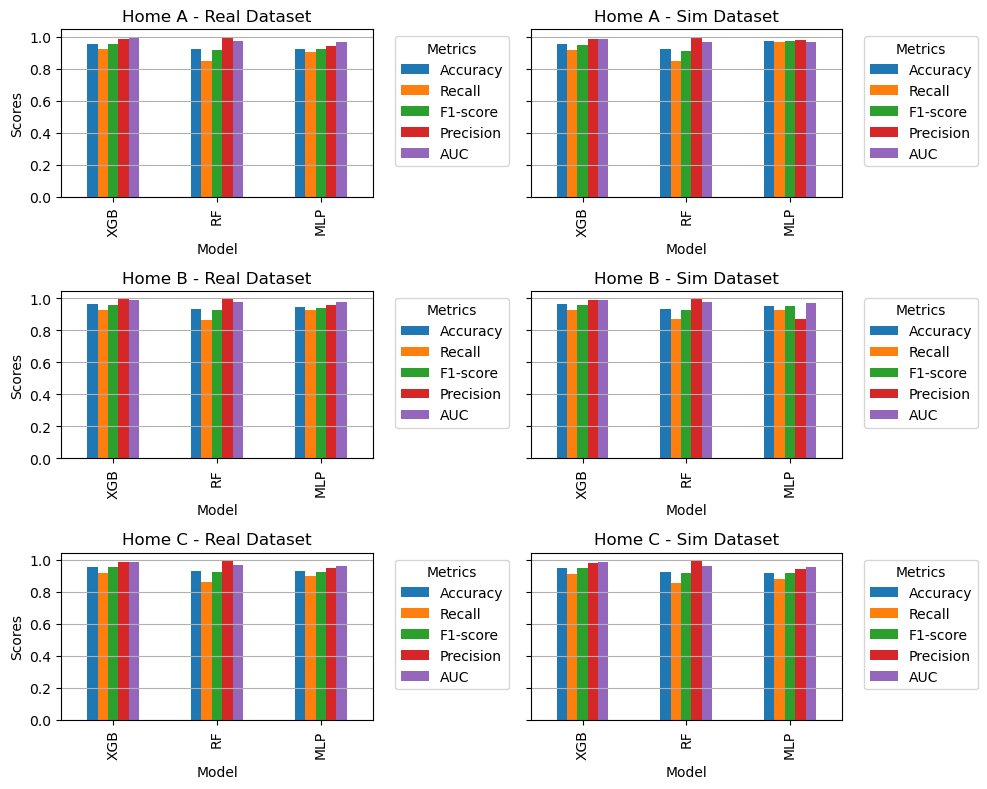

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Redefining the DataFrame from the provided table data
data = {
    "Home": ["A", "A", "A", "A", "A", "A", "B", "B", "B", "B", "B", "B", "C", "C", "C", "C", "C", "C"],
    "DataSet": ["Sim", "Sim", "Sim", "Real", "Real", "Real", "Sim", "Sim", "Sim", "Real", "Real", "Real", "Sim", "Sim", "Sim", "Real", "Real", "Real"],
    "Model": ["XGB", "RF", "MLP", "XGB", "RF", "MLP", "XGB", "RF", "MLP", "XGB", "RF", "MLP", "XGB", "RF", "MLP", "XGB", "RF", "MLP"],
    "Accuracy": [0.9521, 0.9197, 0.9733, 0.9555, 0.9223, 0.9243, 0.9615, 0.9359, 0.9514, 0.9624, 0.9327, 0.9441, 0.9526, 0.9269, 0.9168, 0.9570, 0.9291, 0.9293],
    "Recall": [0.9169, 0.8452, 0.9633, 0.9209, 0.8505, 0.9048, 0.9281, 0.8718, 0.9237, 0.9293, 0.8662, 0.9250, 0.9116, 0.8539, 0.8791, 0.9209, 0.8612, 0.9026],
    "F1-score": [0.9492, 0.9113, 0.9723, 0.9530, 0.9146, 0.9212, 0.9590, 0.9296, 0.9486, 0.9599, 0.9259, 0.9413, 0.9480, 0.9168, 0.9168, 0.9540, 0.9216, 0.9251],
    "Precision": [0.9839, 0.9886, 0.9816, 0.9875, 0.9894, 0.9383, 0.9921, 0.9957, 0.8718, 0.9927, 0.9942, 0.9583, 0.9837, 0.9906, 0.9406, 0.9894, 0.9911, 0.9487],
    "AUC": [0.9876, 0.9647, 0.9656, 0.9891, 0.9702, 0.9668, 0.9878, 0.9756, 0.9724, 0.9878, 0.9764, 0.9795, 0.9853, 0.9625, 0.9537, 0.9853, 0.9654, 0.9649]
}
df = pd.DataFrame(data)

# Adjusting the legend to be outside the graph
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for i, (home, group_df) in enumerate(df.groupby("Home")):
    for j, (dataset, dataset_df) in enumerate(group_df.groupby("DataSet")):
        ax = axes[i * 2 + j]
        dataset_df.set_index("Model")[["Accuracy", "Recall", "F1-score", "Precision", "AUC"]].plot(kind='bar', ax=ax)
        ax.set_title(f'Home {home} - {dataset} Dataset')
        ax.set_xlabel('Model')
        ax.set_ylabel('Scores')
        ax.grid(axis='y')

        # Moving the legend outside of the plot
        ax.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Comparison_across_homes.png', bbox_inches='tight')
plt.show()


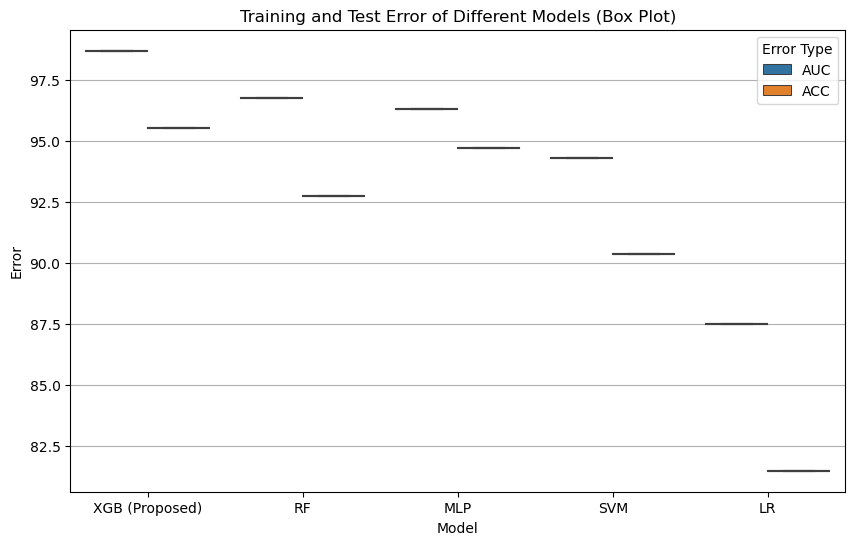

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Manually inputting the data from the image
data = {
    "Model": ["XGB (Proposed)", "RF", "MLP", "SVM", "LR"],
    "AUC": [98.69, 96.76, 96.32, 94.30, 87.48],
    "ACC": [95.54, 92.75, 94.72, 90.34, 81.48]
}

# Creating a DataFrame
df = pd.DataFrame(data)
# Converting the DataFrame to a suitable format for a box plot
df_melted = df.melt(id_vars='Model', var_name='Error Type', value_name='Error')

# Plotting the data as a box plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Model', y='Error', hue='Error Type', data=df_melted)
plt.title('Training and Test Error of Different Models (Box Plot)')
plt.xlabel('Model')
plt.ylabel('Error')
plt.grid(axis='y')
plt.legend(title="Error Type")
plt.show()


<Figure size 500x300 with 0 Axes>

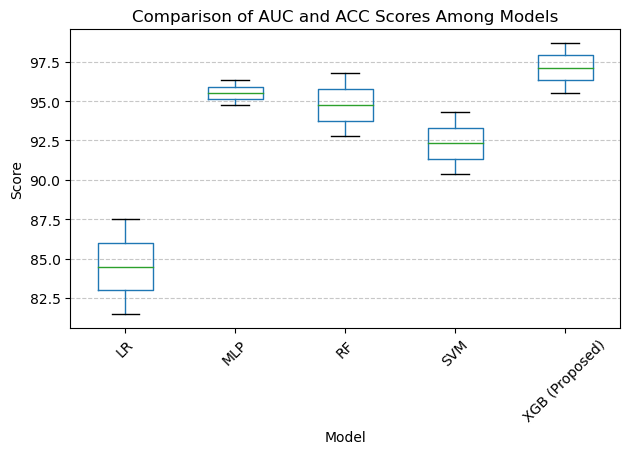

In [13]:
# Since we cannot extract data directly from an image, let's manually input the data based on the provided table
# and generate a box plot for comparison of the models.

import pandas as pd
import matplotlib.pyplot as plt

# Manually inputting the data from the image
data = {
    "Model": ["XGB (Proposed)", "RF", "MLP", "SVM", "LR"],
    "AUC": [98.69, 96.76, 96.32, 94.30, 87.48],
    "ACC": [95.54, 92.75, 94.72, 90.34, 81.48]
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Reshaping the data for box plotting
df_melted = pd.melt(df, id_vars=['Model'], value_vars=['AUC', 'ACC'], var_name='Metric', value_name='Score')

# Plotting the box plot
plt.figure(figsize=(5, 3))
boxplot = df_melted.boxplot(by='Model', column='Score', grid=False, showfliers=True)
plt.title('Comparison of AUC and ACC Scores Among Models')
plt.suptitle('')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Comparison_with_other_models.png', bbox_inches='tight')
plt.show()


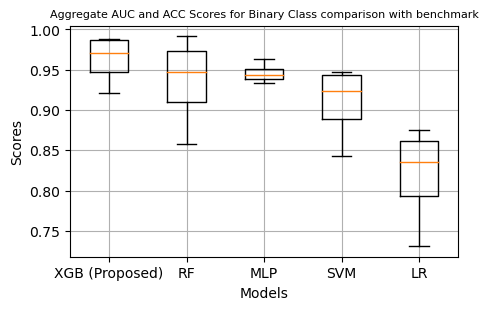

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from the table
data = {
    "XGB (Proposed)": [0.9554, 0.9213, 0.9882, 0.9869],
    "RF": [0.9275, 0.8581, 0.9916, 0.9676],
    "MLP": [0.9331, 0.9472, 0.9399, 0.9632],
    "SVM": [0.9035, 0.8432, 0.9471, 0.9430],
    "LR": [0.8148, 0.7311, 0.8565, 0.8748]
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Plotting the box plot
plt.figure(figsize=(5, 3))
# boxplot = df_melted.boxplot(by='Model', column='Score', grid=False, showfliers=True)
plt.boxplot(df, labels=df.columns, vert=True)
plt.title("Aggregate AUC and ACC Scores for Binary Class comparison with benchmark", fontsize=8 )
plt.ylabel("Scores")
plt.xlabel("Models")
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Benchmark_Comparison_AUC_ACC_models.png', bbox_inches='tight')
plt.show()

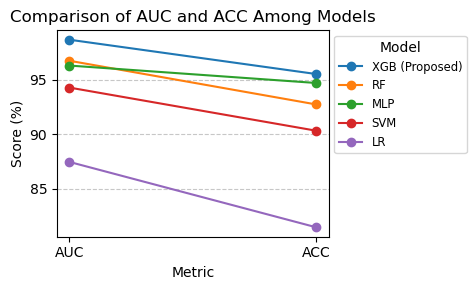

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Manually inputting the data from the image
data = {
    "Model": ["XGB (Proposed)", "RF", "MLP", "SVM", "LR"],
    "AUC": [98.69, 96.76, 96.32, 94.30, 87.48],
    "ACC": [95.54, 92.75, 94.72, 90.34, 81.48]
}
#######################################
# Plotting the data as a line plot with a smaller legend outside the graph
fig, ax = plt.subplots(figsize=(5, 3))

# Plotting each model's AUC and ACC
for index, row in df.iterrows():
    ax.plot(['AUC', 'ACC'], [row['AUC'], row['ACC']], marker='o', label=row['Model'])

plt.title('Comparison of AUC and ACC Among Models')
plt.xlabel('Metric')
plt.ylabel('Score (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjusting the legend size and placing it outside the plot area
ax.legend(title="Model", fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Comparison_with_other_mdel.png', bbox_inches='tight')
plt.show()


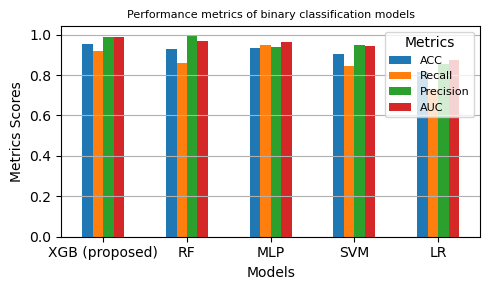

In [26]:
# It seems that the OCR output is not perfectly structured, but we have enough information to create a DataFrame
# Let's manually create the DataFrame with the data extracted

# Data from OCR output
data = {
    "Model": ["XGB (proposed)", "RF", "MLP", "SVM", "LR"],
    "ACC": [95.54, 92.75, 93.31, 90.35, 81.48],
    "Recall": [92.13, 85.81, 94.72, 84.32, 73.11],
    "Precision": [98.82, 99.16, 93.99, 94.71, 85.65],
    "AUC": [98.69, 96.76, 96.32, 94.30, 87.48]
}

# Convert percentages to fractions
for key in data:
    if key != 'Model':
        data[key] = [value/100 for value in data[key]]

# Create the DataFrame
df = pd.DataFrame(data)

# Plotting the performance metrics against the models
fig, ax = plt.subplots(figsize=(5, 3))
df.set_index('Model').plot(kind='bar', ax=ax)
plt.title('Performance metrics of binary classification models', fontsize=8)
plt.xlabel('Models')
plt.ylabel('Metrics Scores')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title="Metrics", fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\model_comp_binary.png', bbox_inches='tight')
plt.show()


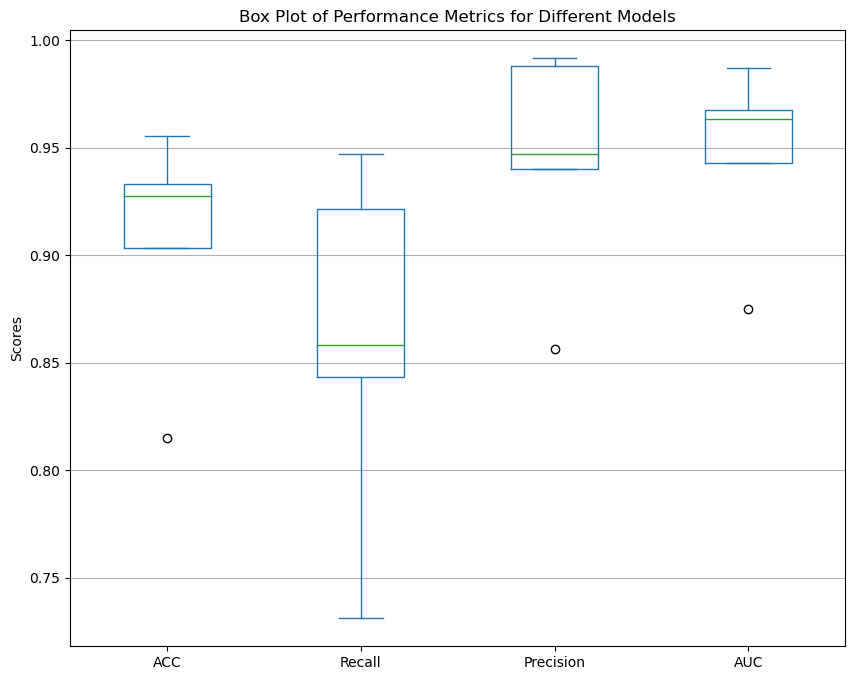

In [9]:
# Data from OCR output
data = {
    "Model": ["XGB (Proposed)", "RF", "MLP", "SVM", "LR"],
    "ACC": [95.54, 92.75, 93.31, 90.35, 81.48],
    "Recall": [92.13, 85.81, 94.72, 84.32, 73.11],
    "Precision": [98.82, 99.16, 93.99, 94.71, 85.65],
    "AUC": [98.69, 96.76, 96.32, 94.30, 87.48]
}

# Convert percentages to fractions
for key in data:
    if key != 'Model':
        data[key] = [value/100 for value in data[key]]

# Create the DataFrame
df = pd.DataFrame(data)
# Generating a boxplot for the performance metrics of the different models
fig, ax = plt.subplots(figsize=(10, 8))
df.set_index('Model').plot(kind='box', ax=ax)

plt.title('Box Plot of Performance Metrics for Different Models')
plt.ylabel('Scores')
plt.grid(axis='y')
plt.show()


### Comparison performance Analysis with Synthetic Binary Descriminator

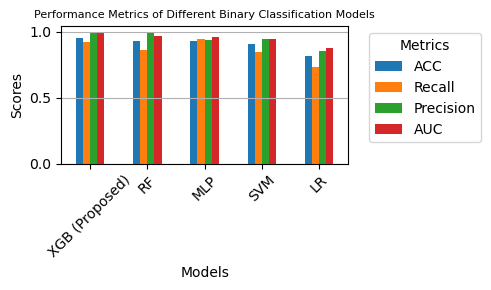

In [20]:
# Since the previous OCR output and manual data entry were successful, we'll use that data to create the plot

# Data from previous OCR output
data = {
    "Model": ["XGB (Proposed)", "RF", "MLP", "SVM", "LR"],
    "ACC": [95.54, 92.75, 93.31, 90.35, 81.48],
    "Recall": [92.13, 85.81, 94.72, 84.32, 73.11],
    "Precision": [98.82, 99.16, 93.99, 94.71, 85.65],
    "AUC": [98.69, 96.76, 96.32, 94.30, 87.48]
}

# Convert percentages to fractions
for key in data:
    if key != 'Model':
        data[key] = [value/100 for value in data[key]]

# Create the DataFrame
df = pd.DataFrame(data)

# Plotting the performance metrics against the models with legend outside the plot
fig, ax = plt.subplots(figsize=(6, 3))
df.set_index('Model').plot(kind='bar', ax=ax)
plt.title('Performance Metrics of Different Binary Classification Models', fontsize=8)
plt.xlabel('Models')
plt.ylabel('Scores')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust the right edge of the plot window
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Journal_review\Comparison_with_other_mdels.png', bbox_inches='tight')
plt.show()


In [18]:
# Re-importing pandas as the previous execution state was reset and we lost all the imported modules.
import pandas as pd

# Summary of the model performances
summary_data = {
    'Metric': ['ACC', 'Recall', 'Precision', 'AUC'],
    'XGB (Proposed)': [0.9554, 0.9213, 0.9882, 0.9869],
    'RF': [0.9275, 0.8581, 0.9916, 0.9676],
    'MLP': [0.9331, 0.9472, 0.9399, 0.9632],
    'SVM': [0.9035, 0.8432, 0.9471, 0.9430],
    'LR': [0.8148, 0.7311, 0.8565, 0.8748]
}

# Convert the summary data to a DataFrame
summary_df = pd.DataFrame(summary_data)

# Set 'Metric' as the index
summary_df.set_index('Metric', inplace=True)

# Display the DataFrame as a table
summary_df


,XGB (Proposed),RF,MLP,SVM,LR
Metric,,,,,
ACC,0.9554,0.9275,0.9331,0.9035,0.8148
Recall,0.9213,0.8581,0.9472,0.8432,0.7311
Precision,0.9882,0.9916,0.9399,0.9471,0.8565
AUC,0.9869,0.9676,0.9632,0.9430,0.8748
